In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

#***Load Dataset:-***

In [39]:
#load dataset
df=pd.read_csv('/content/prostate_cancer_prediction.csv')

In [4]:
df.head()

,Patient_ID,Age,Family_History,Race_African_Ancestry,PSA_Level,DRE_Result,Biopsy_Result,Difficulty_Urinating,Weak_Urine_Flow,Blood_in_Urine,...,Alcohol_Consumption,Hypertension,Diabetes,Cholesterol_Level,Screening_Age,Follow_Up_Required,Prostate_Volume,Genetic_Risk_Factors,Previous_Cancer_History,Early_Detection
0,1,78,No,Yes,5.07,Normal,Benign,No,No,No,...,Moderate,No,No,Normal,45,No,46.0,No,No,Yes
1,2,68,No,Yes,10.24,Normal,Benign,Yes,No,No,...,Low,No,No,High,65,No,78.2,No,No,Yes
2,3,54,No,No,13.79,Normal,Benign,No,No,No,...,Low,No,No,Normal,61,No,21.1,No,No,Yes
3,4,82,No,No,8.03,Abnormal,Benign,No,No,No,...,Low,No,No,Normal,47,Yes,79.9,No,Yes,Yes
4,5,47,Yes,No,1.89,Normal,Malignant,Yes,Yes,No,...,Moderate,Yes,No,Normal,72,No,32.0,No,No,Yes


In [5]:
#shape
df.shape

(27945, 30)

#***EDA(Explotary Data Anlysis):-***

In [6]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27945 entries, 0 to 27944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               27945 non-null  int64  
 1   Age                      27945 non-null  int64  
 2   Family_History           27945 non-null  object 
 3   Race_African_Ancestry    27945 non-null  object 
 4   PSA_Level                27945 non-null  float64
 5   DRE_Result               27945 non-null  object 
 6   Biopsy_Result            27945 non-null  object 
 7   Difficulty_Urinating     27945 non-null  object 
 8   Weak_Urine_Flow          27945 non-null  object 
 9   Blood_in_Urine           27945 non-null  object 
 10  Pelvic_Pain              27945 non-null  object 
 11  Back_Pain                27945 non-null  object 
 12  Erectile_Dysfunction     27945 non-null  object 
 13  Cancer_Stage             27945 non-null  object 
 14  Treatment_Recommended 

In [40]:
#drop column patient_id
df.drop('Patient_ID',axis=1,inplace=True)

In [8]:
#dataset describe
df.describe()

,Age,PSA_Level,BMI,Screening_Age,Prostate_Volume
count,27945.000000,27945.000000,27945.000000,27945.000000,27945.000000
mean,64.459939,7.751599,26.511605,56.902308,47.755770
std,14.404755,4.175012,4.888293,10.118064,18.704286
min,40.000000,0.500000,18.000000,40.000000,15.000000
25%,52.000000,4.130000,22.300000,48.000000,31.700000
50%,64.000000,7.750000,26.500000,57.000000,47.700000
75%,77.000000,11.320000,30.700000,66.000000,63.900000
max,89.000000,15.000000,35.000000,74.000000,80.000000


In [9]:
#missing values
df.isnull().sum()

,0
Age,0
Family_History,0
Race_African_Ancestry,0
PSA_Level,0
DRE_Result,0
Biopsy_Result,0
Difficulty_Urinating,0
Weak_Urine_Flow,0
Blood_in_Urine,0
Pelvic_Pain,0


In [10]:
#check the duplicated column
df.duplicated().sum()

0

In [41]:
cate_col=df.select_dtypes(include='object').columns
cate_col

Index(['Family_History', 'Race_African_Ancestry', 'DRE_Result',
       'Biopsy_Result', 'Difficulty_Urinating', 'Weak_Urine_Flow',
       'Blood_in_Urine', 'Pelvic_Pain', 'Back_Pain', 'Erectile_Dysfunction',
       'Cancer_Stage', 'Treatment_Recommended', 'Survival_5_Years',
       'Exercise_Regularly', 'Healthy_Diet', 'Smoking_History',
       'Alcohol_Consumption', 'Hypertension', 'Diabetes', 'Cholesterol_Level',
       'Follow_Up_Required', 'Genetic_Risk_Factors', 'Previous_Cancer_History',
       'Early_Detection'],
      dtype='object')

In [12]:
#numerical column
num_col=df.select_dtypes(exclude='object').columns
num_col

Index(['Age', 'PSA_Level', 'BMI', 'Screening_Age', 'Prostate_Volume'], dtype='object')

#***Data Visualization:-***

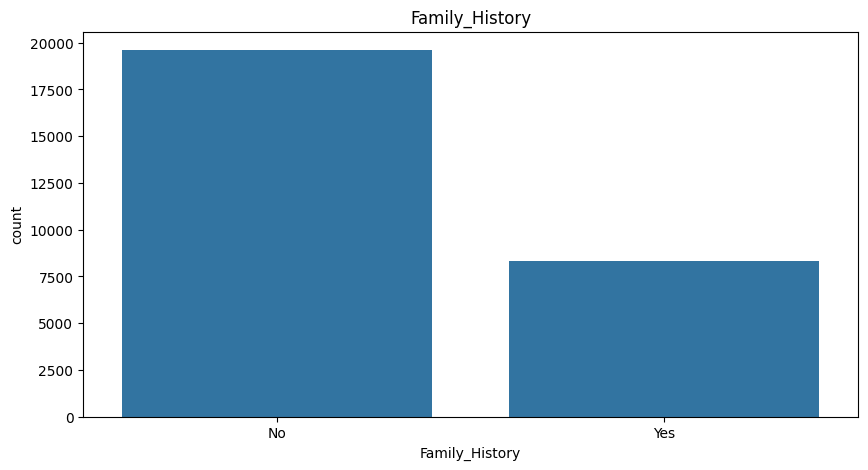

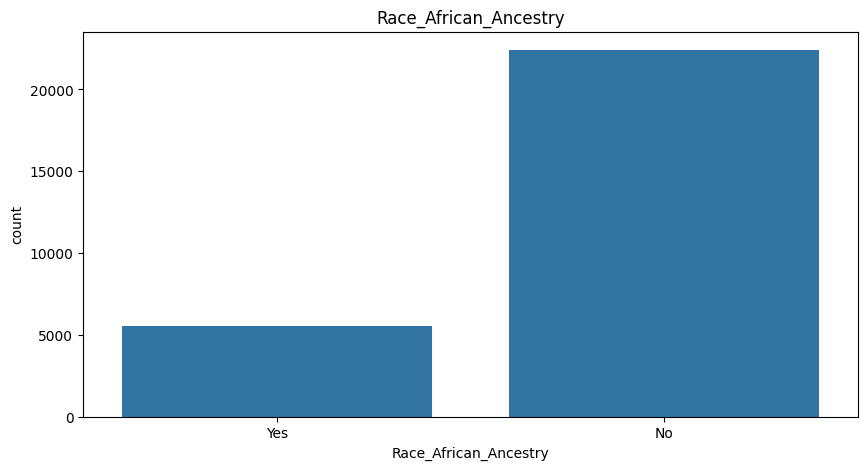

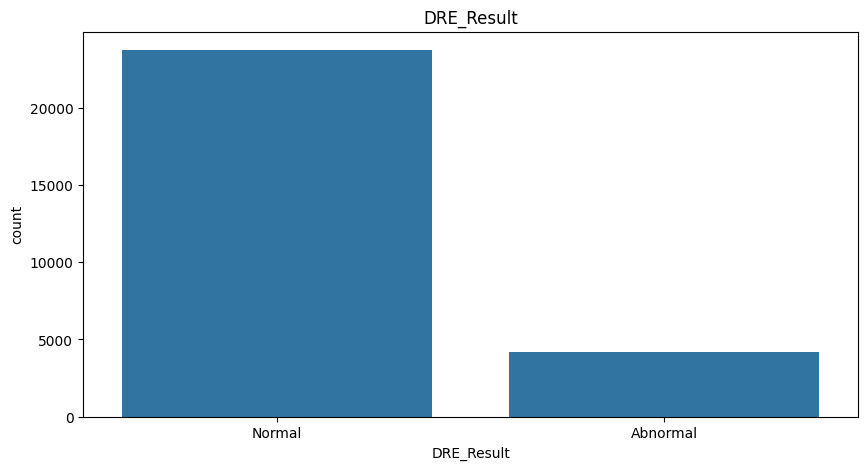

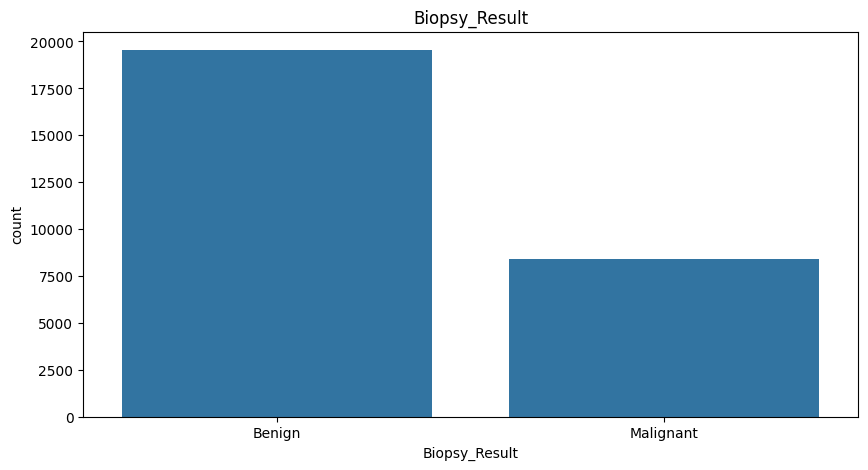

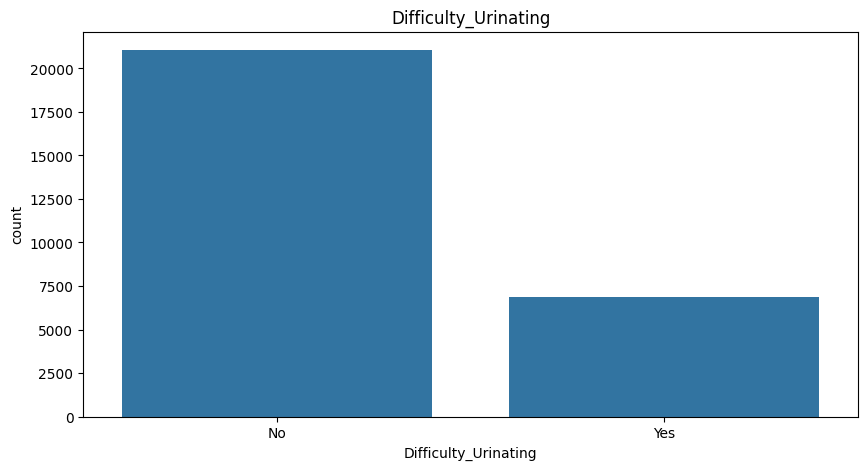

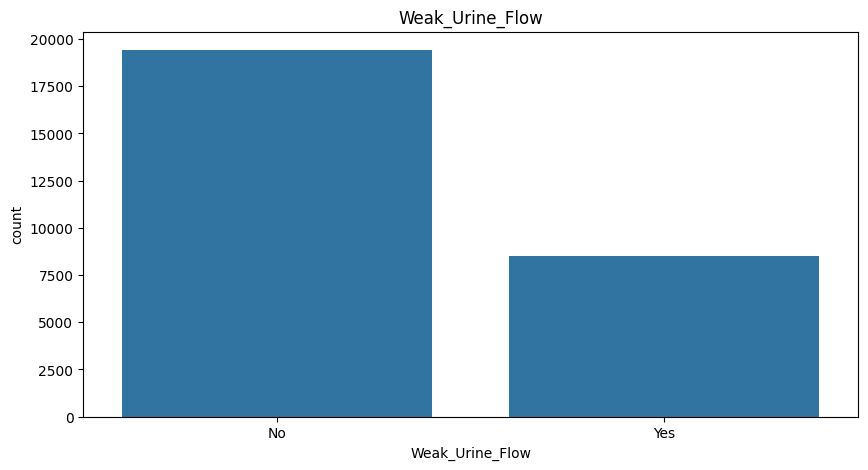

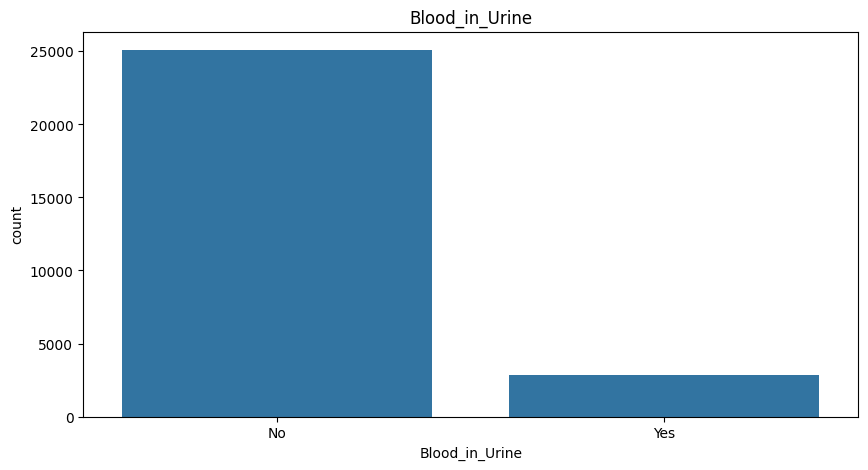

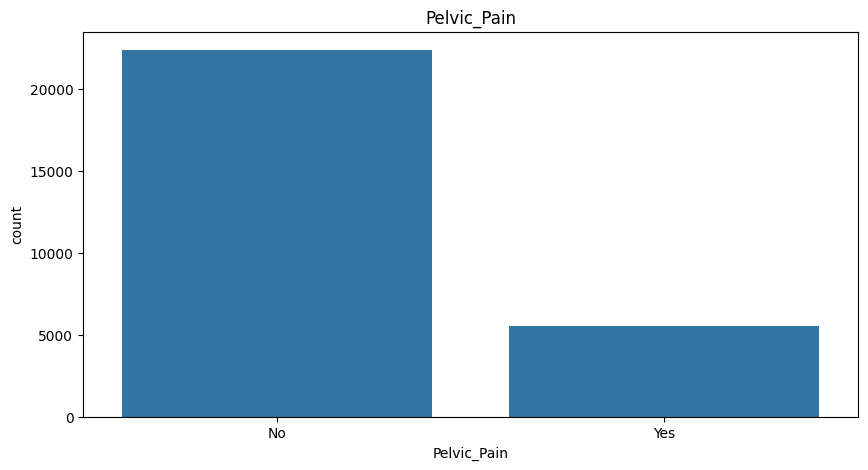

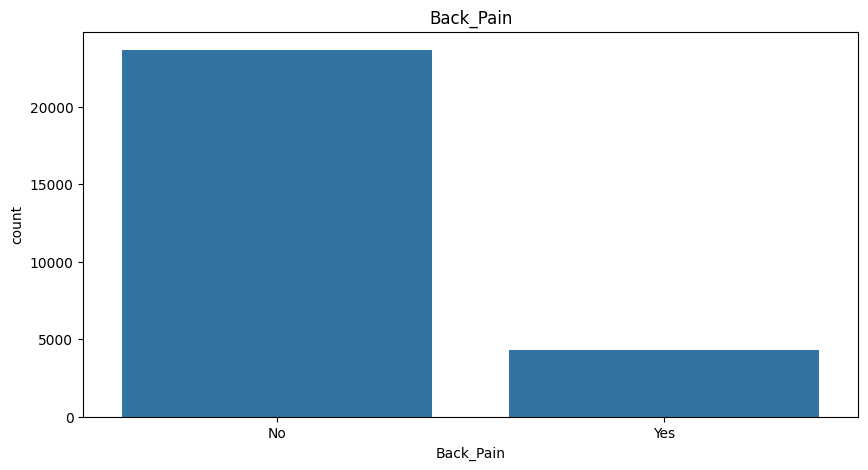

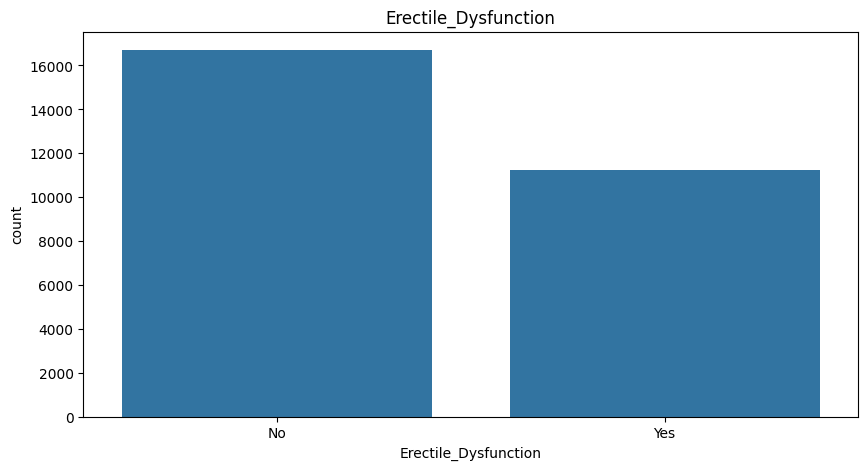

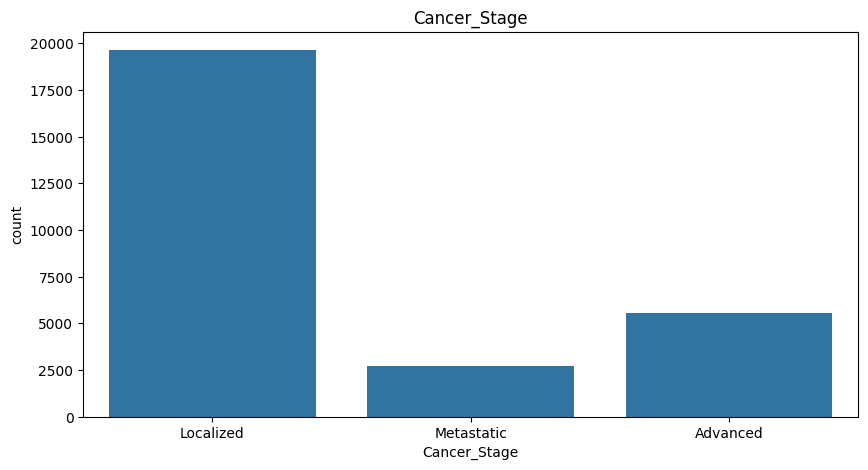

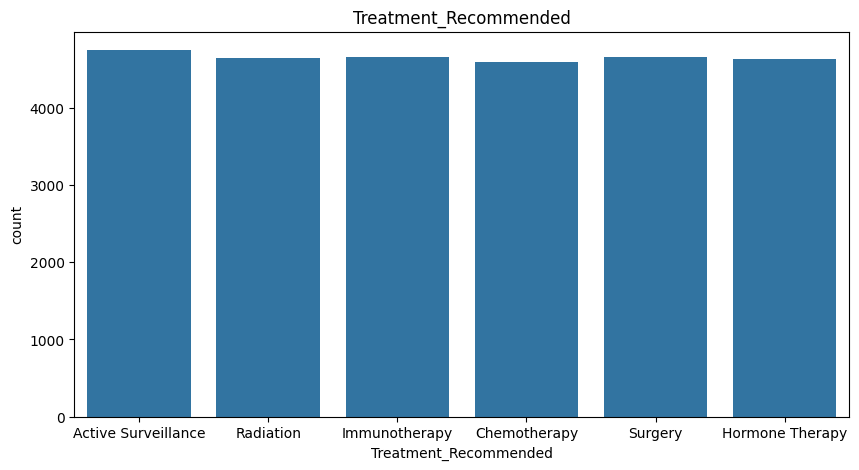

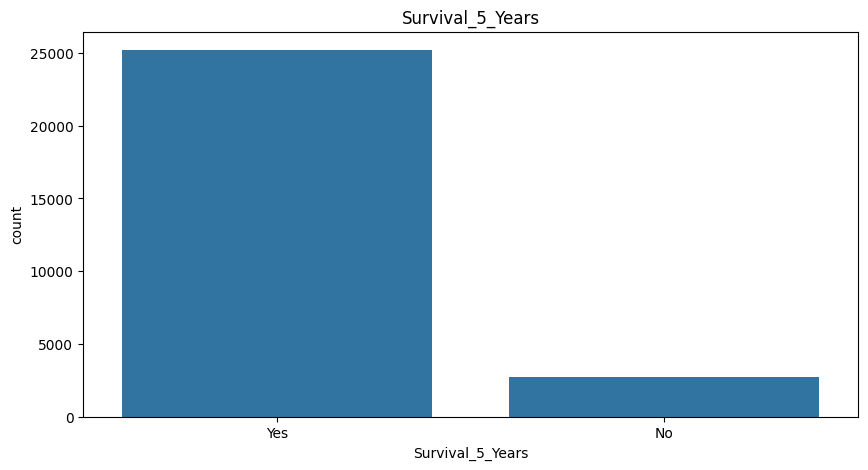

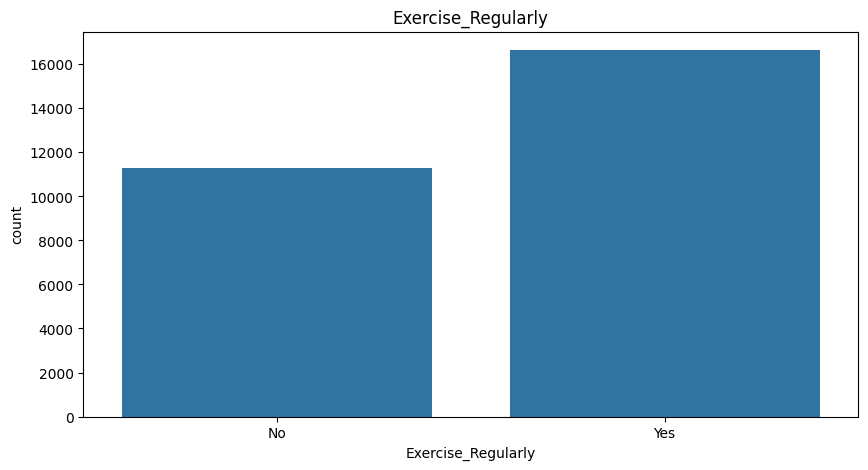

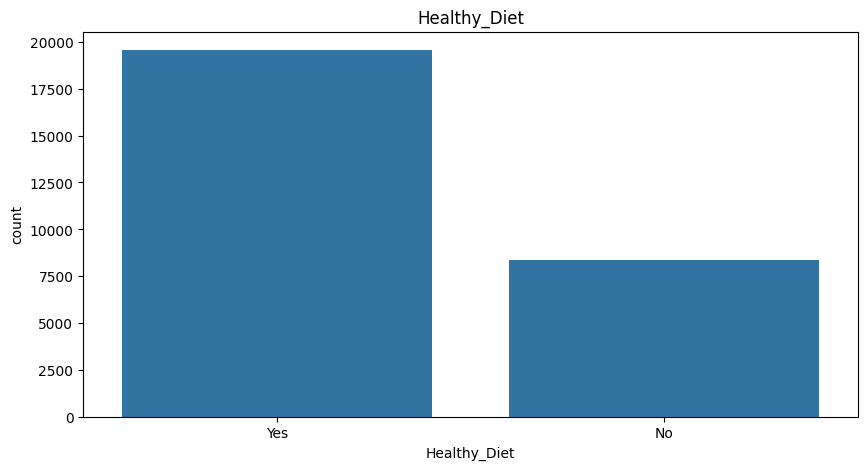

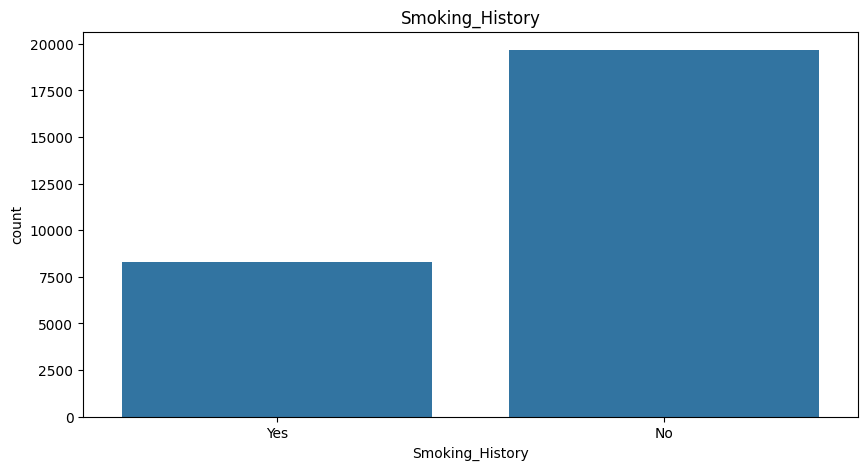

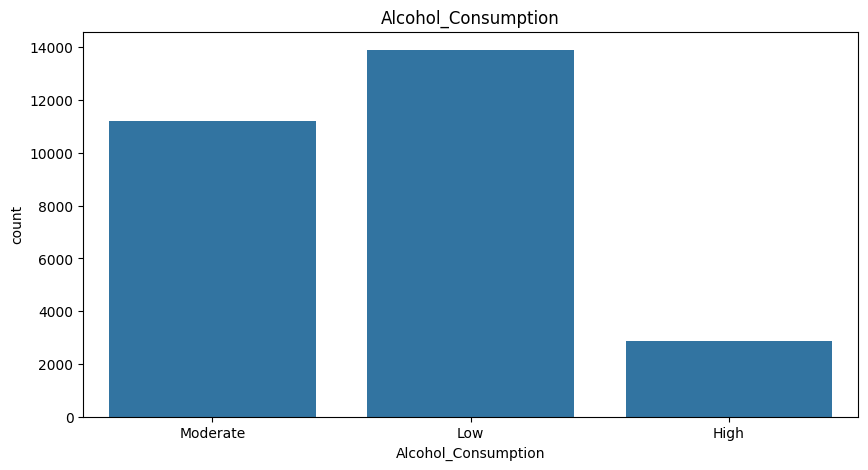

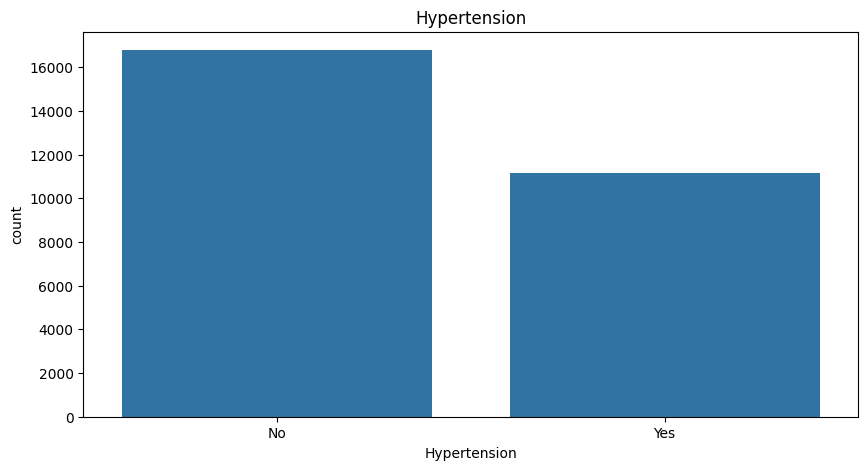

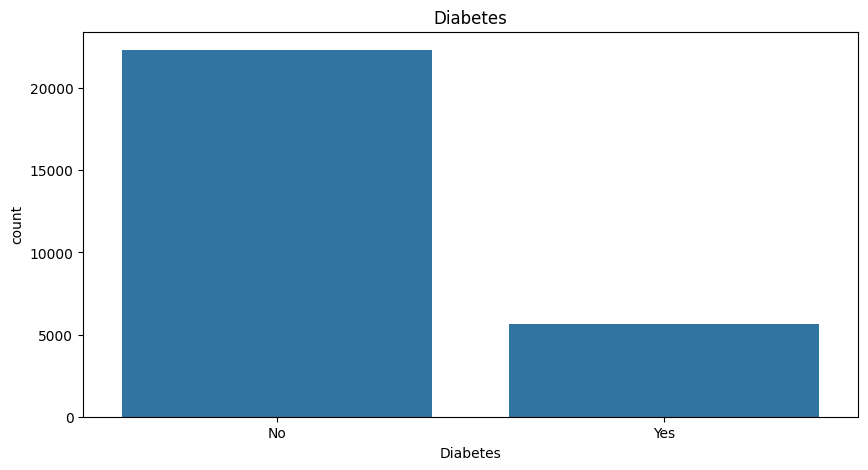

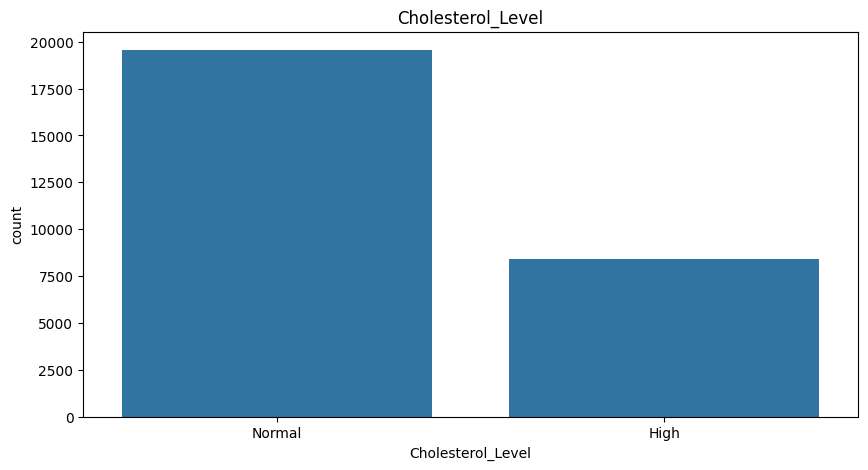

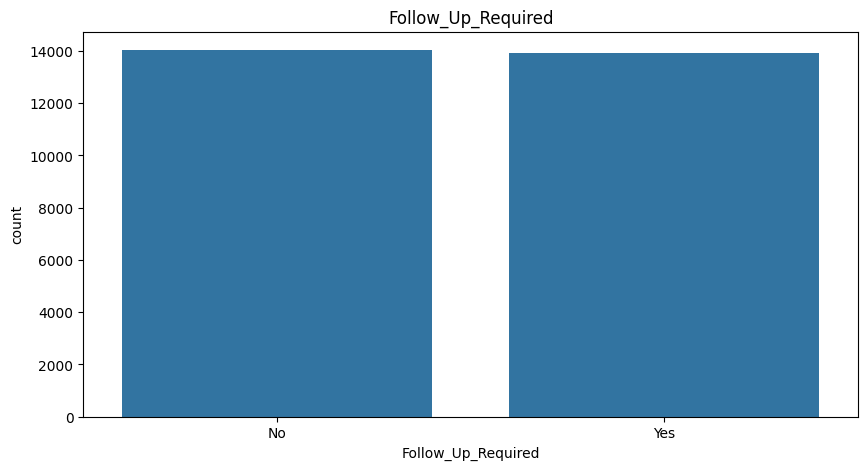

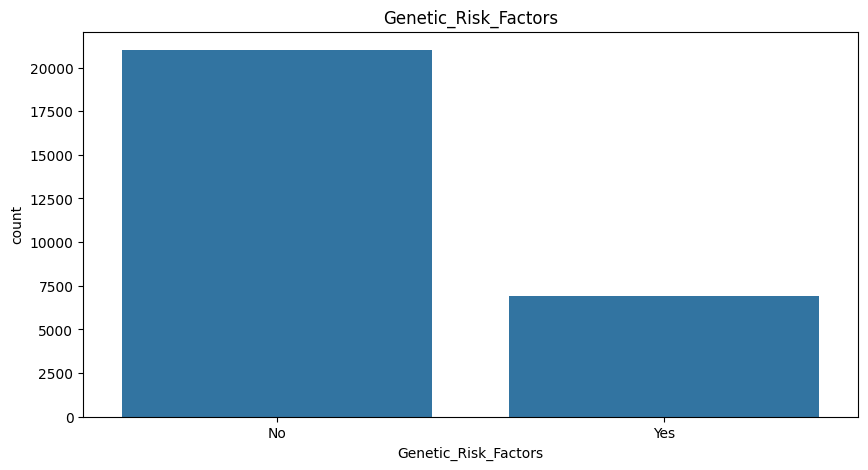

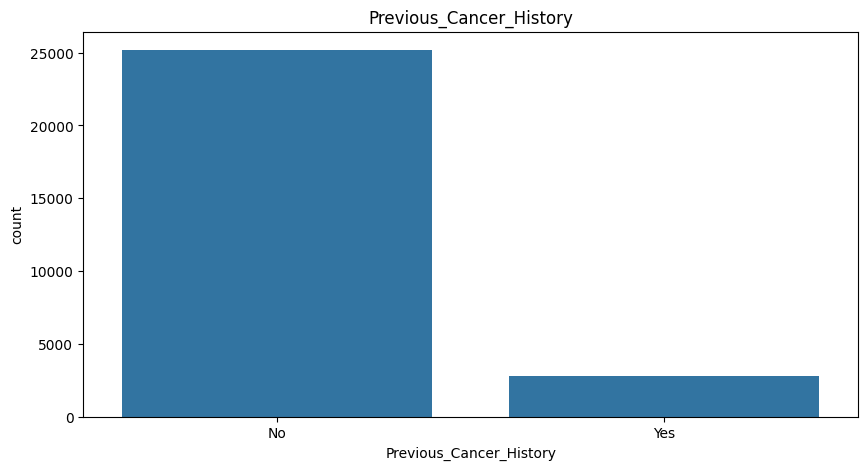

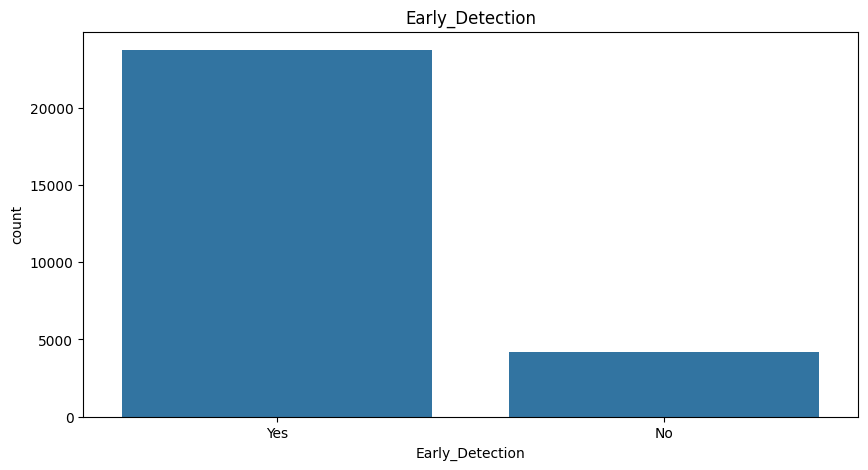

In [13]:
#categorical column visualization
for i in cate_col:
  plt.figure(figsize=(10,5))
  sns.countplot(x=df[i])
  plt.title(i)
  plt.show()

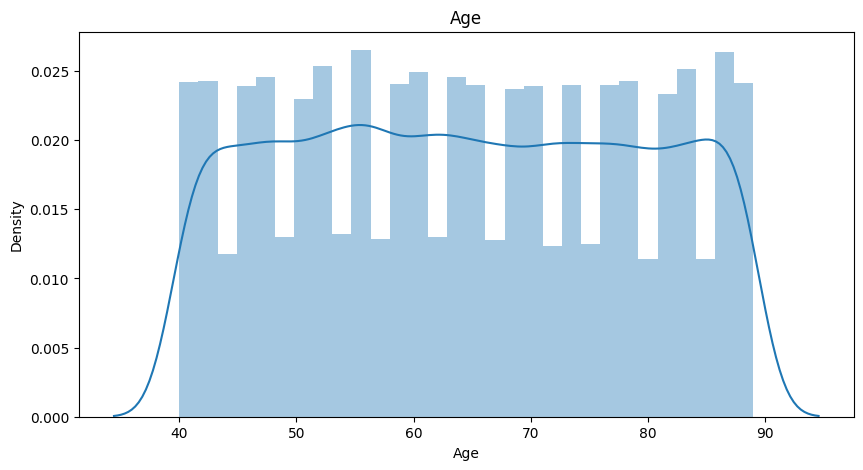

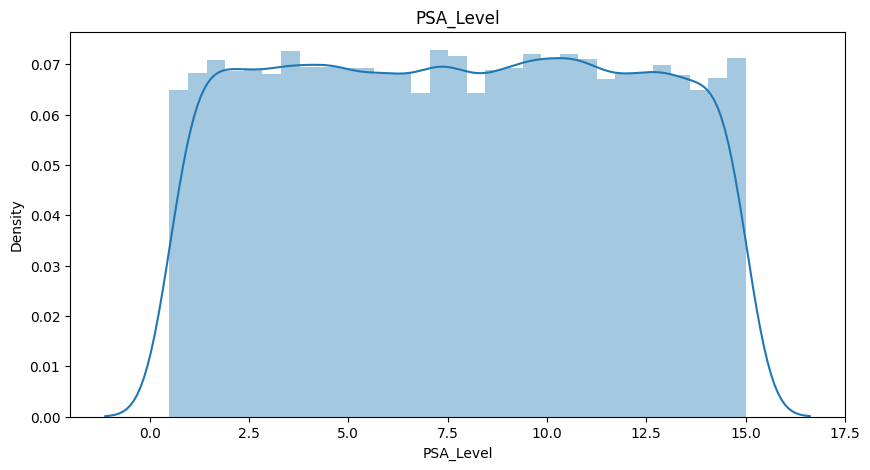

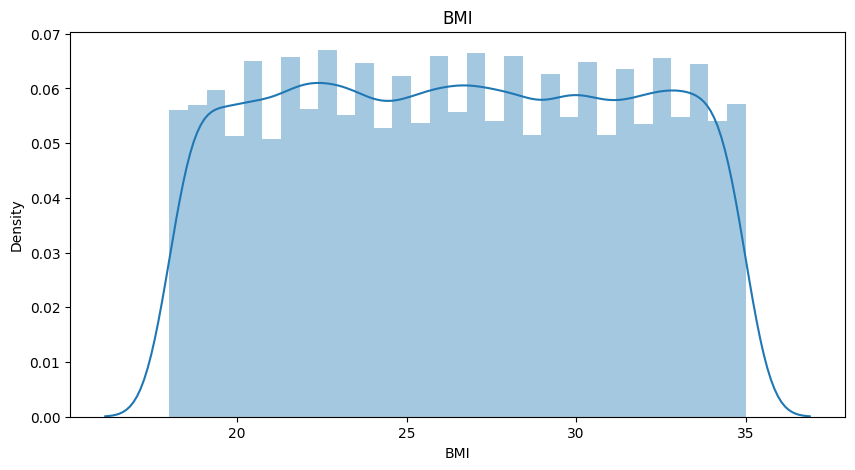

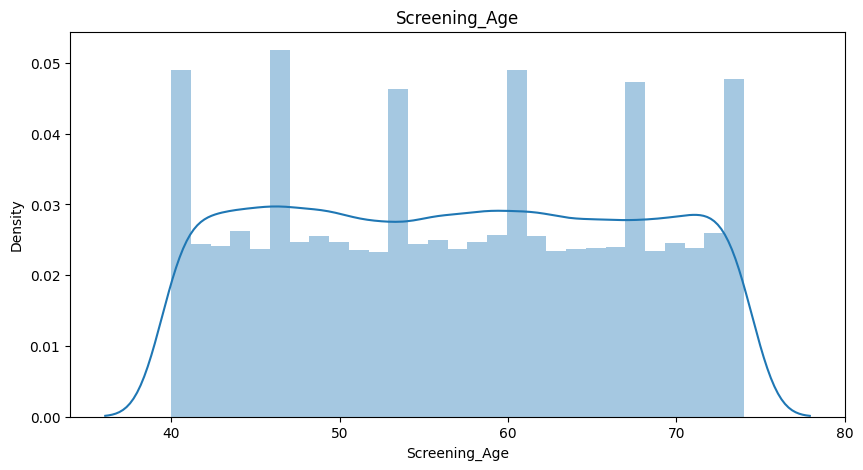

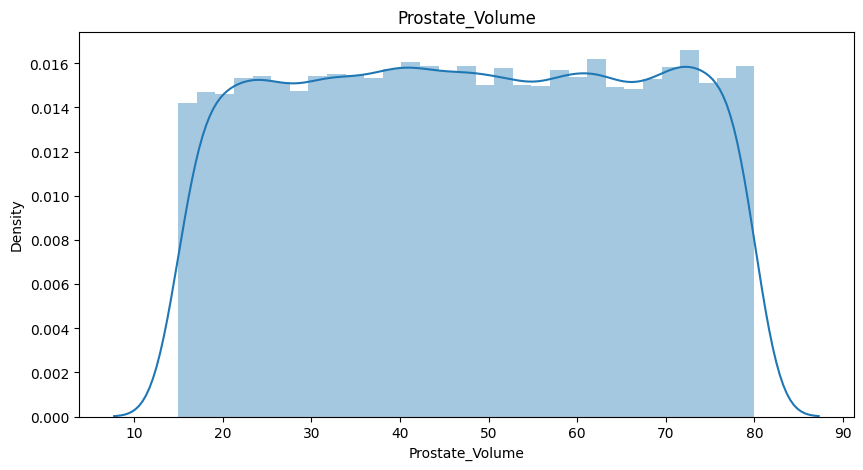

In [14]:
#Numerical column distribution
for i in num_col:
  plt.figure(figsize=(10,5))
  sns.distplot(df[i])
  plt.title(i)
  plt.show()

In [15]:
df.columns

Index(['Age', 'Family_History', 'Race_African_Ancestry', 'PSA_Level',
       'DRE_Result', 'Biopsy_Result', 'Difficulty_Urinating',
       'Weak_Urine_Flow', 'Blood_in_Urine', 'Pelvic_Pain', 'Back_Pain',
       'Erectile_Dysfunction', 'Cancer_Stage', 'Treatment_Recommended',
       'Survival_5_Years', 'Exercise_Regularly', 'Healthy_Diet', 'BMI',
       'Smoking_History', 'Alcohol_Consumption', 'Hypertension', 'Diabetes',
       'Cholesterol_Level', 'Screening_Age', 'Follow_Up_Required',
       'Prostate_Volume', 'Genetic_Risk_Factors', 'Previous_Cancer_History',
       'Early_Detection'],
      dtype='object')

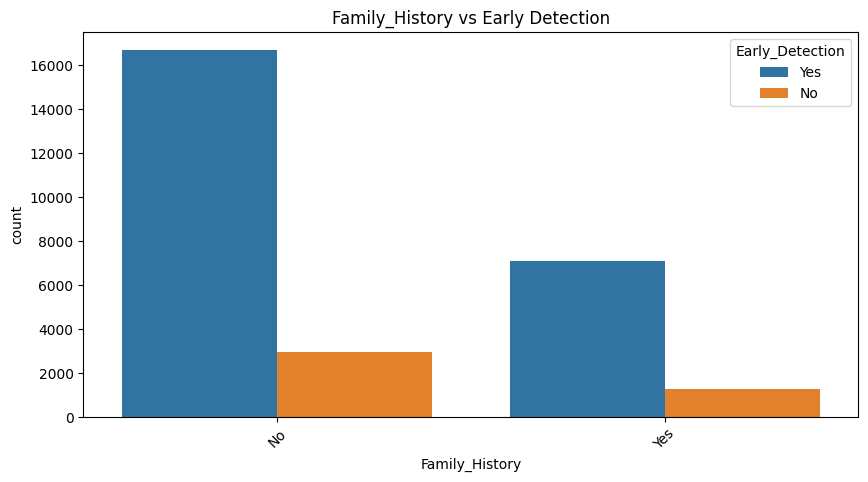

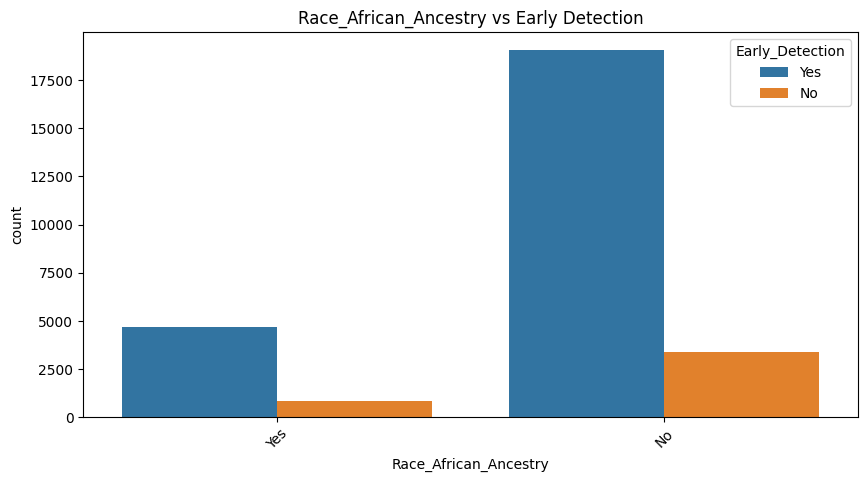

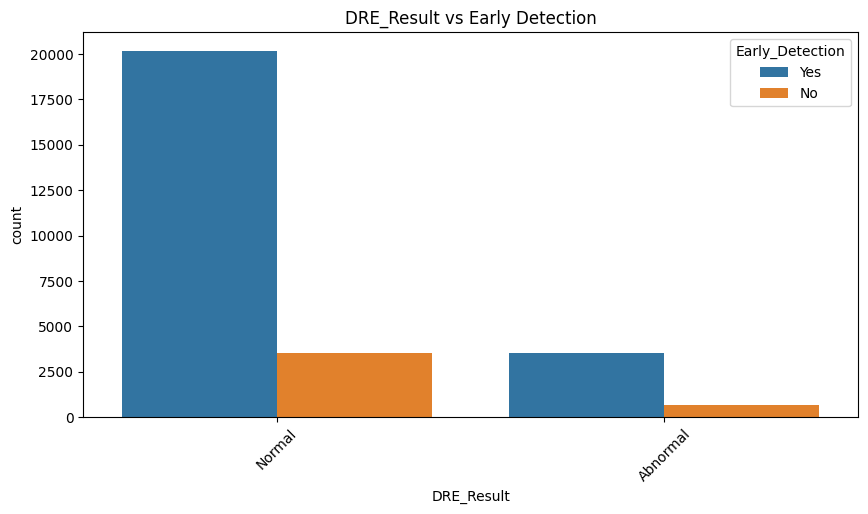

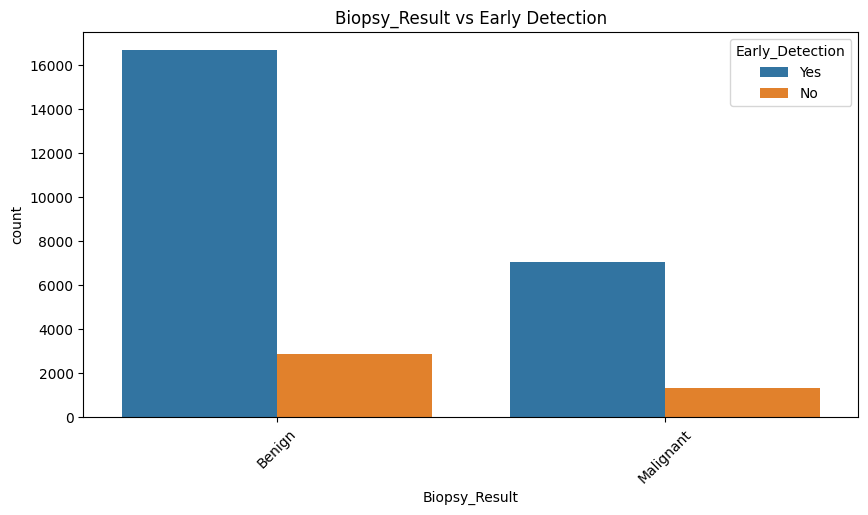

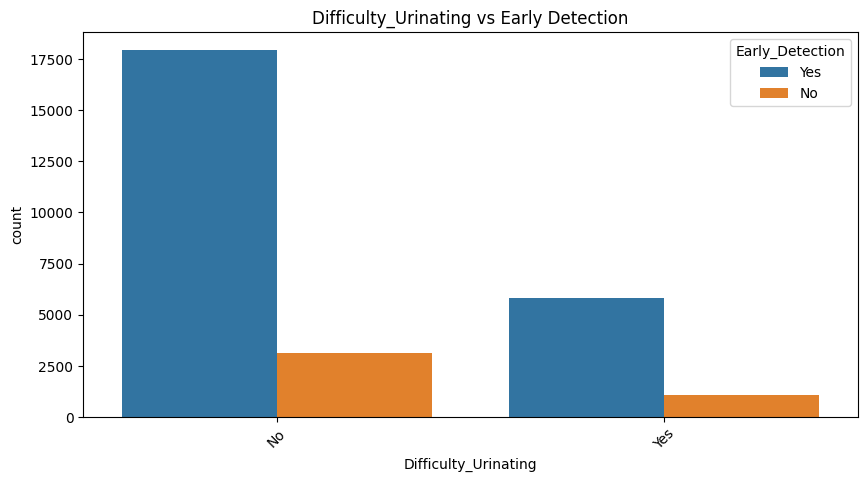

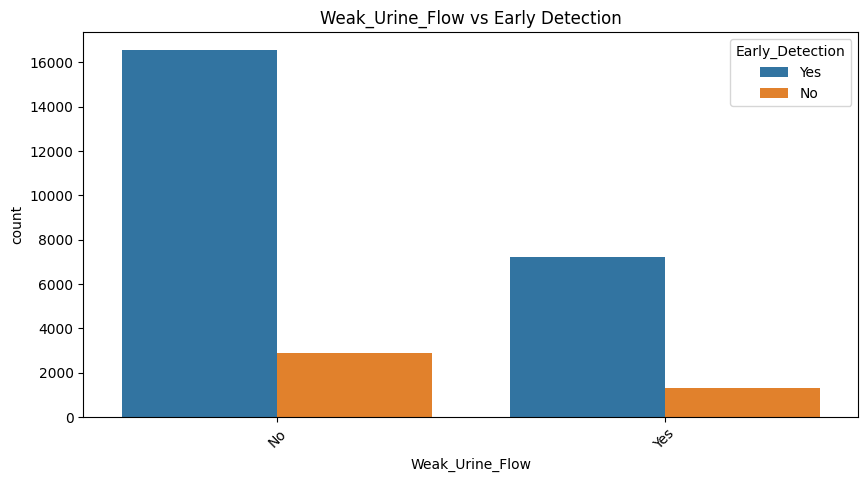

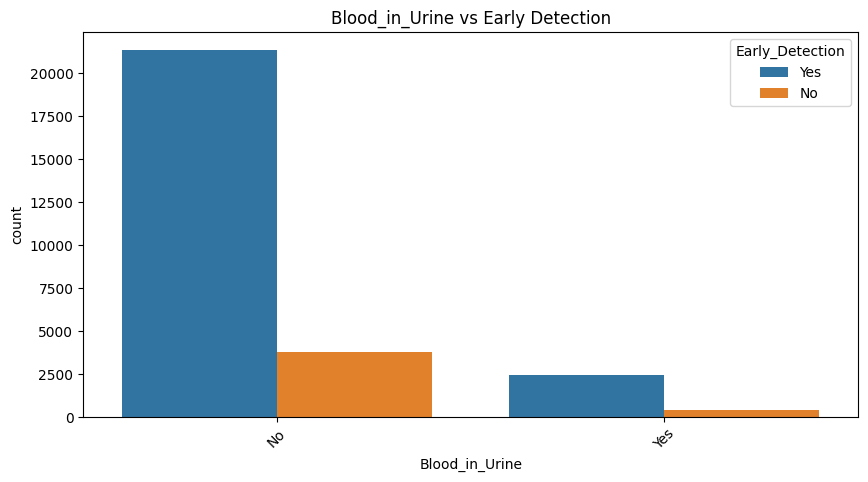

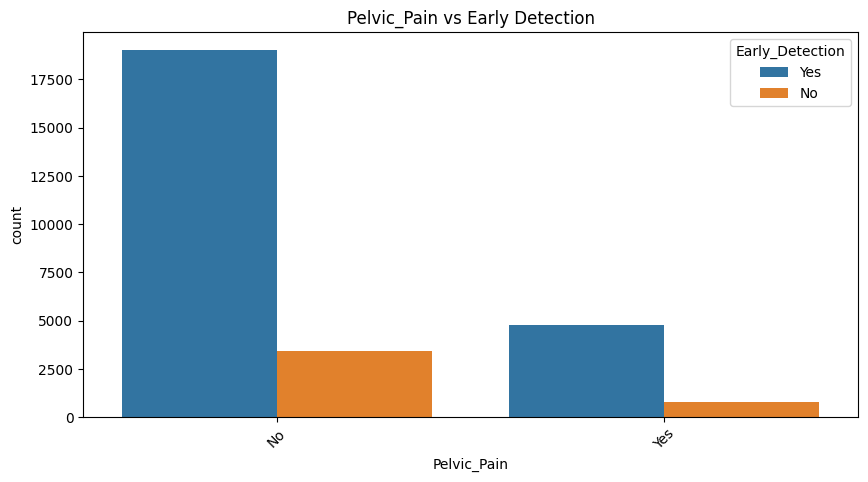

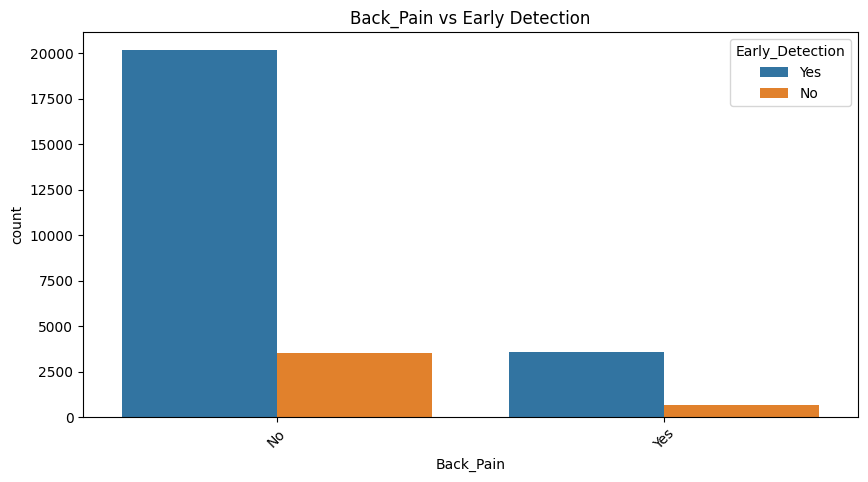

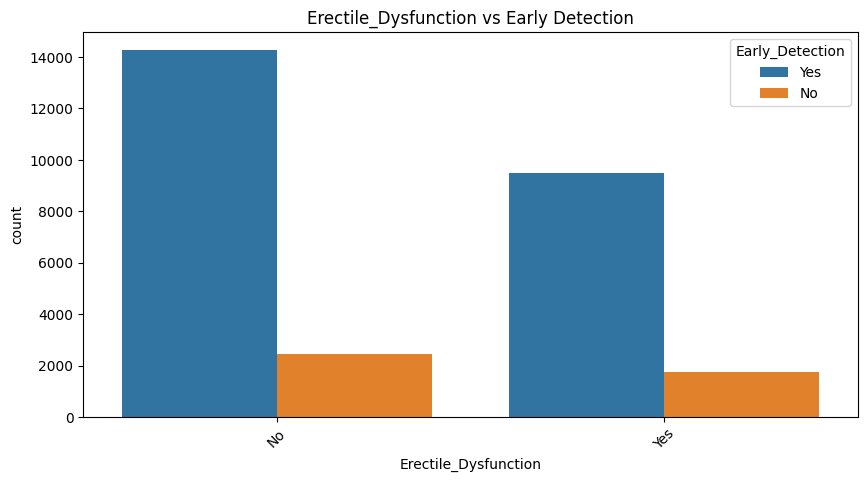

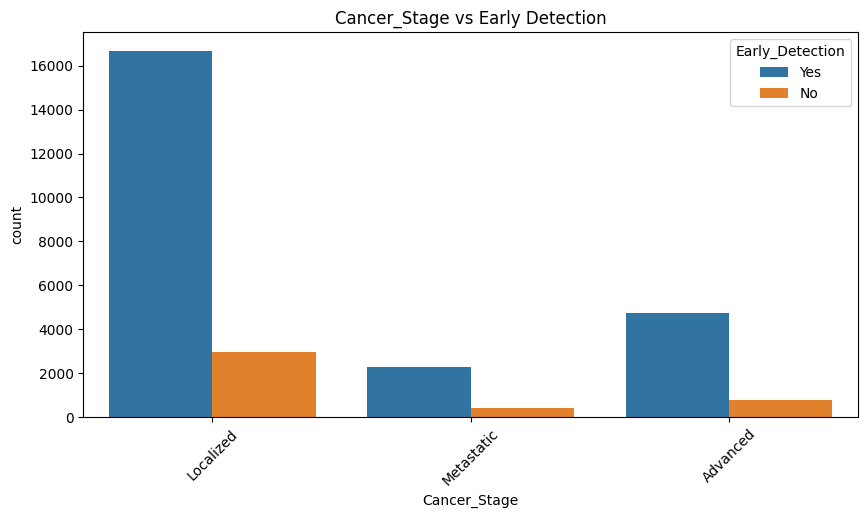

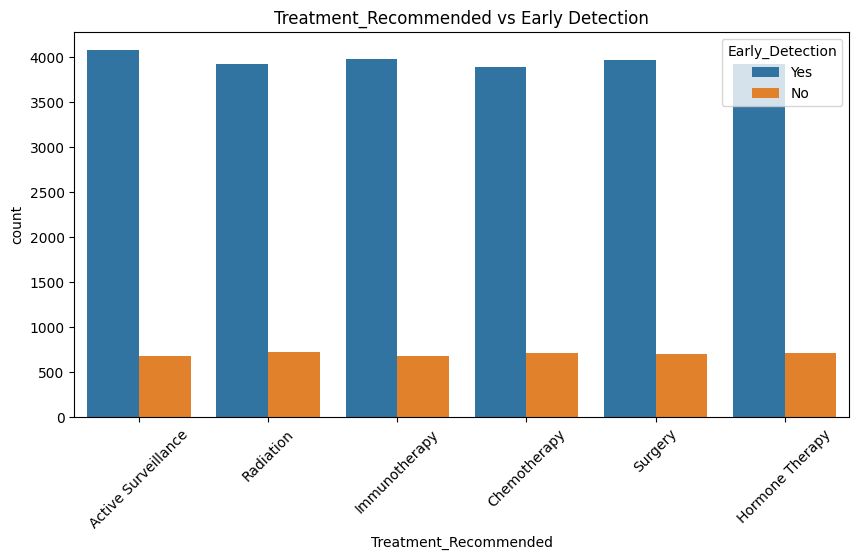

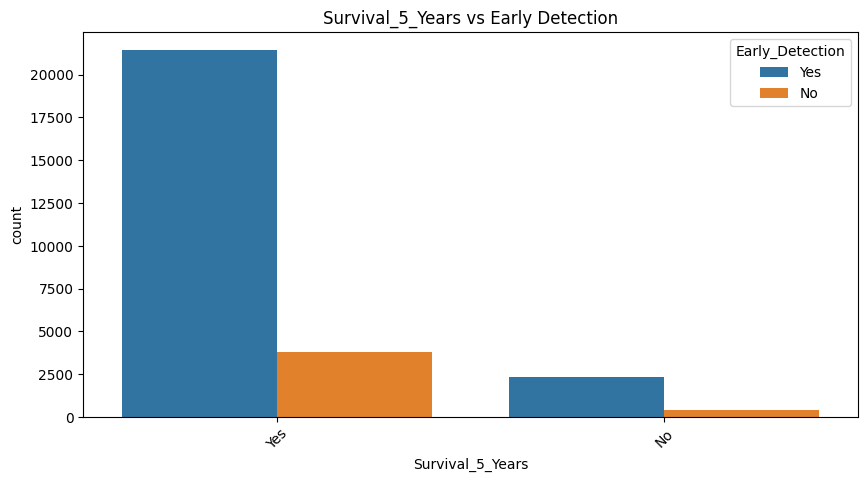

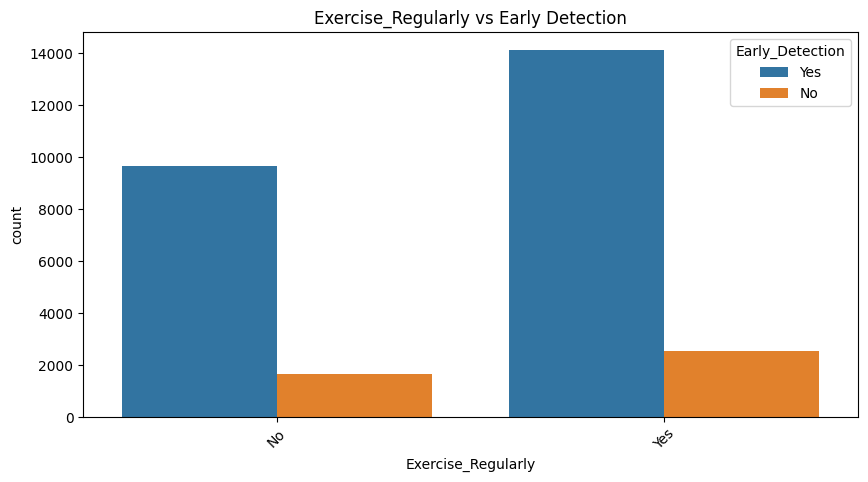

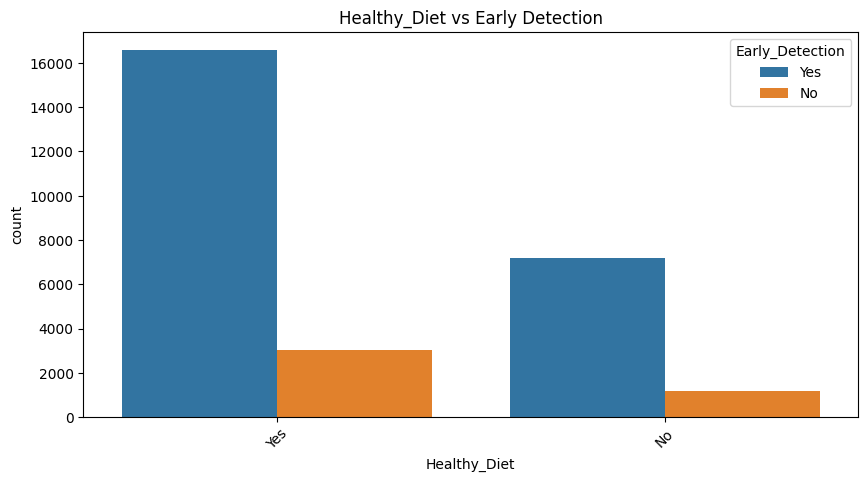

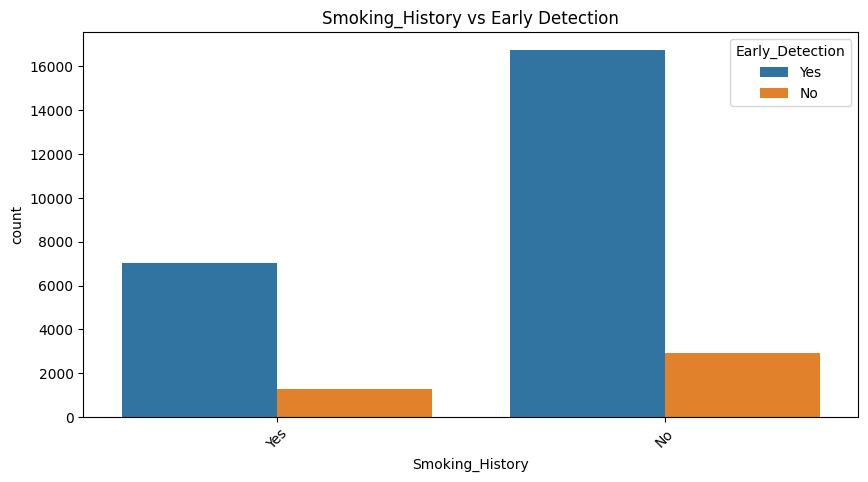

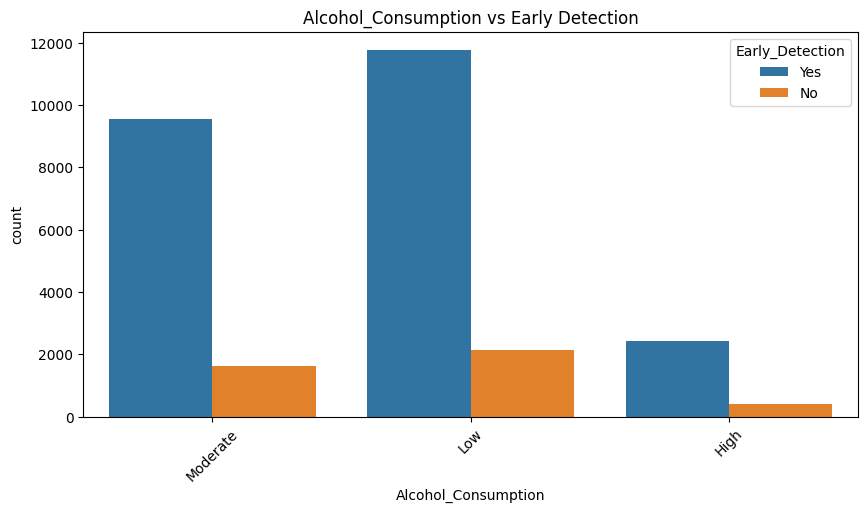

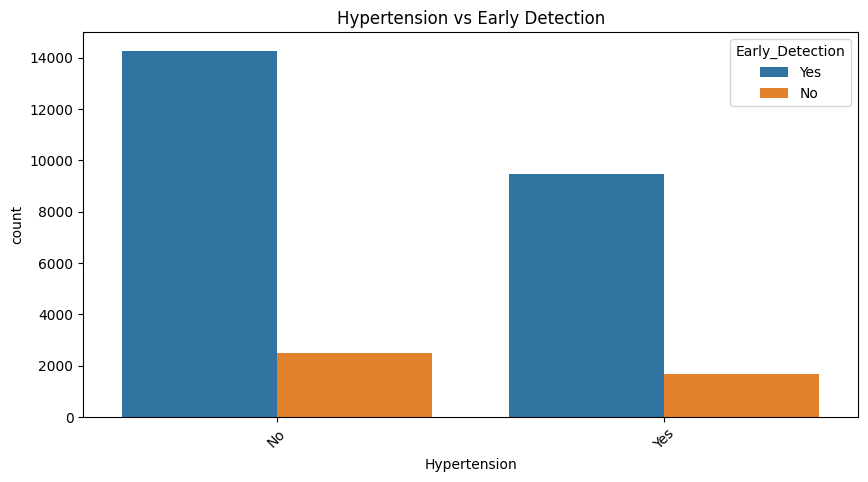

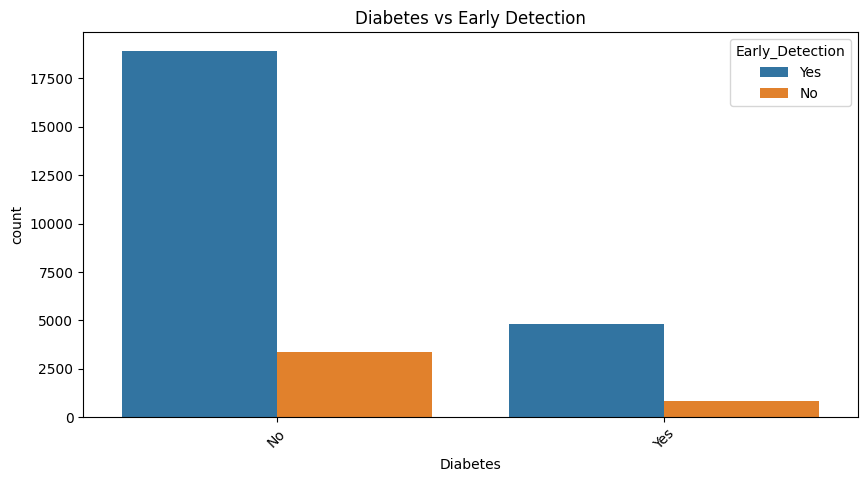

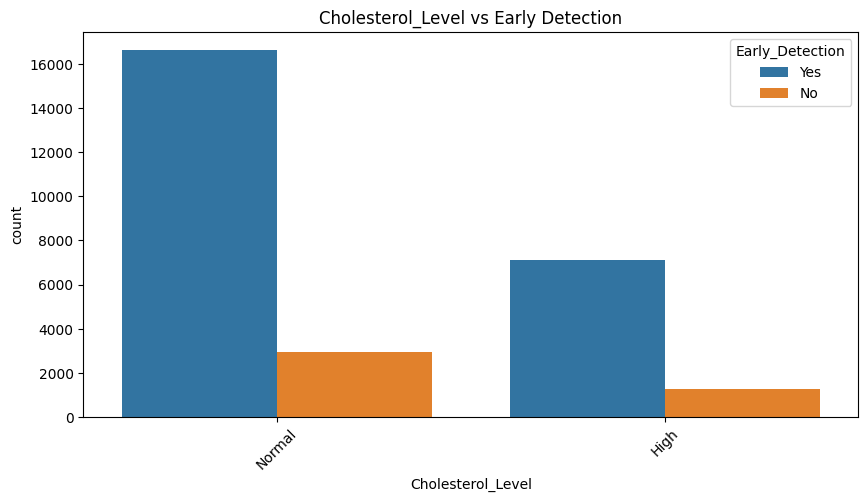

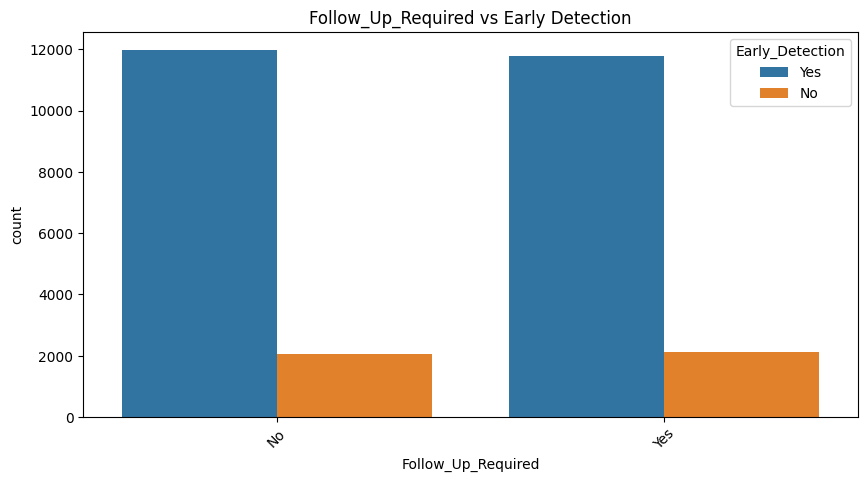

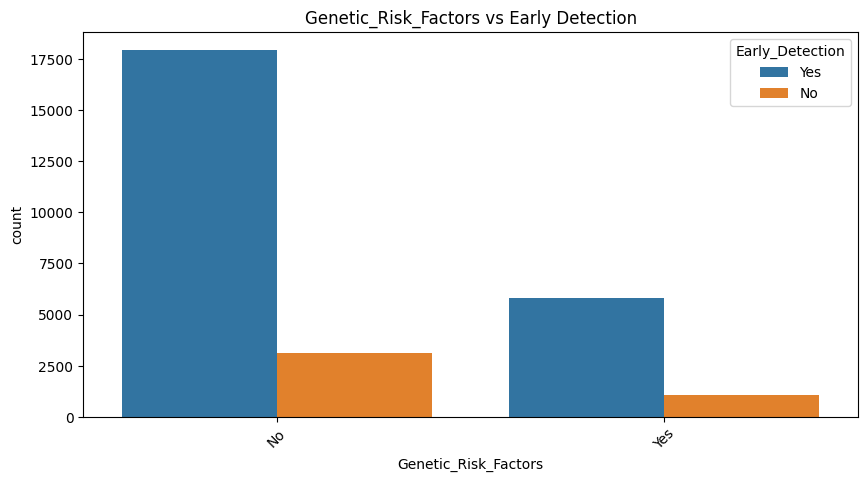

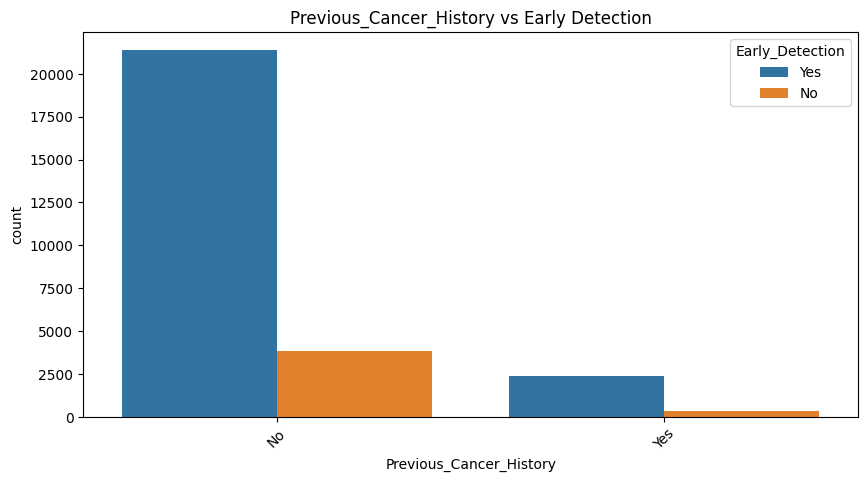

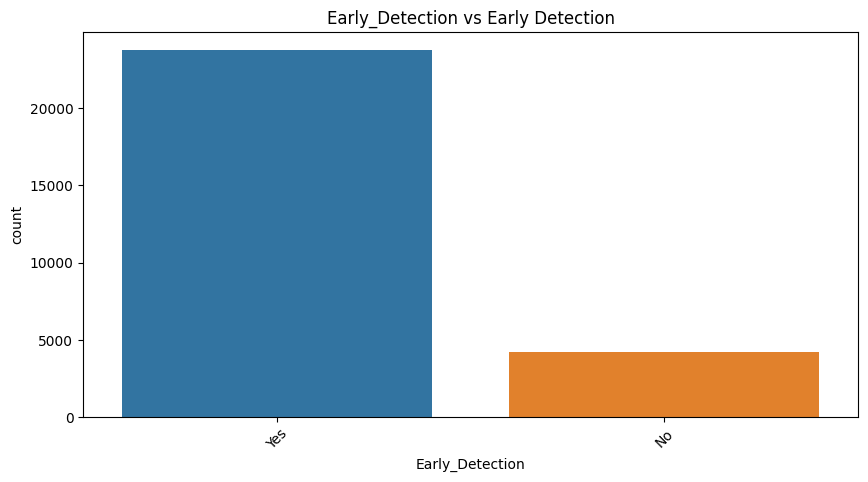

In [16]:
#data visualization of target column
for i in cate_col:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=i, hue="Early_Detection", data=df)
    plt.title(f"{i} vs Early Detection")
    plt.xticks(rotation=45)
    plt.show()

#***Encoding:-***

In [42]:
#label encoding
encoder={}
for col in cate_col:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  encoder[col]=le

In [43]:
encoder

{'Family_History': LabelEncoder(),
 'Race_African_Ancestry': LabelEncoder(),
 'DRE_Result': LabelEncoder(),
 'Biopsy_Result': LabelEncoder(),
 'Difficulty_Urinating': LabelEncoder(),
 'Weak_Urine_Flow': LabelEncoder(),
 'Blood_in_Urine': LabelEncoder(),
 'Pelvic_Pain': LabelEncoder(),
 'Back_Pain': LabelEncoder(),
 'Erectile_Dysfunction': LabelEncoder(),
 'Cancer_Stage': LabelEncoder(),
 'Treatment_Recommended': LabelEncoder(),
 'Survival_5_Years': LabelEncoder(),
 'Exercise_Regularly': LabelEncoder(),
 'Healthy_Diet': LabelEncoder(),
 'Smoking_History': LabelEncoder(),
 'Alcohol_Consumption': LabelEncoder(),
 'Hypertension': LabelEncoder(),
 'Diabetes': LabelEncoder(),
 'Cholesterol_Level': LabelEncoder(),
 'Follow_Up_Required': LabelEncoder(),
 'Genetic_Risk_Factors': LabelEncoder(),
 'Previous_Cancer_History': LabelEncoder(),
 'Early_Detection': LabelEncoder()}

#***Correlation:-***

In [18]:
# Compute correlation of numerical features with the target column
correlation = df.corr()["Early_Detection"].drop("Early_Detection")  # Drop target itself

# Sort by absolute correlation (optional)
correlation = correlation.sort_values(ascending=False)

In [19]:
correlation

,Early_Detection
Previous_Cancer_History,0.012725
Pelvic_Pain,0.008006
Diabetes,0.005572
DRE_Result,0.005494
Alcohol_Consumption,0.005180
Blood_in_Urine,0.001434
Survival_5_Years,-0.000122
PSA_Level,-0.000176
Family_History,-0.000653
Race_African_Ancestry,-0.001096


***Correlation Bar chart:-***

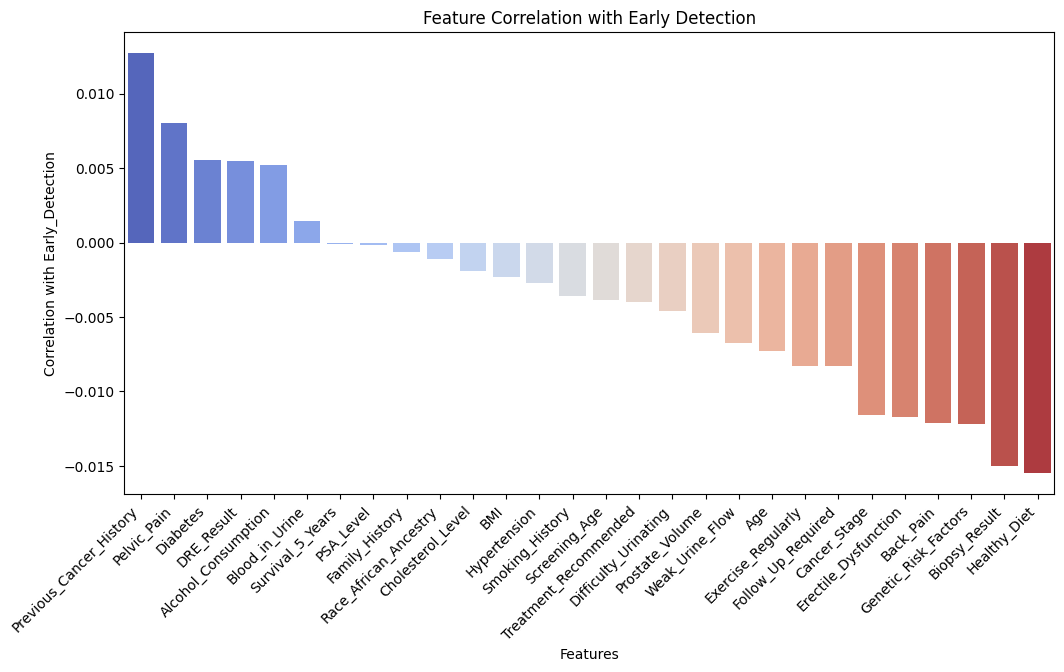

In [20]:
# Plot the correlation as a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=correlation.index, y=correlation.values, palette="coolwarm")

# Customize plot
plt.xticks(rotation=45, ha='right')
plt.xlabel("Features")
plt.ylabel("Correlation with Early_Detection")
plt.title("Feature Correlation with Early Detection")
plt.show()

#***Split the dataset:-***

In [44]:
X=df.drop('Early_Detection',axis=1)
y=df['Early_Detection']

In [22]:
y.value_counts()

,count
Early_Detection,
1,23747
0,4198


#***Blancing Target column:-***

In [23]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
X,y=sm.fit_resample(X,y)

#***Feature selection:-***

In [24]:
rfc=RandomForestClassifier()
rfc.fit(X,y)

RandomForestClassifier()

In [25]:
# Get feature importance
feature_importances = pd.DataFrame(rfc.feature_importances_,
                                   index=X.columns,
                                   columns=['Importance']).sort_values('Importance', ascending=False)

# Display the feature importance
print(feature_importances)


                         Importance
Prostate_Volume            0.086783
PSA_Level                  0.083833
BMI                        0.082905
Age                        0.076676
Screening_Age              0.073355
Treatment_Recommended      0.048494
Alcohol_Consumption        0.045650
Family_History             0.037028
Hypertension               0.032924
Difficulty_Urinating       0.031550
Pelvic_Pain                0.030437
Smoking_History            0.030186
Diabetes                   0.029217
Weak_Urine_Flow            0.027958
Follow_Up_Required         0.026157
Cancer_Stage               0.025284
Erectile_Dysfunction       0.024793
Genetic_Risk_Factors       0.023230
Race_African_Ancestry      0.022970
Biopsy_Result              0.022570
Exercise_Regularly         0.021521
Cholesterol_Level          0.020875
Back_Pain                  0.018093
Healthy_Diet               0.017582
Blood_in_Urine             0.016571
Previous_Cancer_History    0.016467
DRE_Result                 0

#***Drop the Least Correlated Feature and Feature selection :-***
❌Features That Come After Cancer Detection (Should Be Dropped for Prediction)
These features are typically observed after cancer has already been detected:\

Biopsy_Result → Confirms cancer, but happens after suspicion.\
Cancer_Stage → Assigned only after diagnosis.\
Treatment_Recommended → Treatment is suggested only after confirmation.\
Follow_Up_Required → Only required for diagnosed cases.\
Survival_5_Years → Only relevant after cancer treatment.

Features That Are Useful for Predicting Cancer (Should Be Kept)
These features help detect cancer before it happens:

✅ Risk Factors:\

Family_History → Genetic predisposition.\
Genetic_Risk_Factors → BRCA1, BRCA2 mutations increase risk.\
Age → Older age = higher risk.\
Smoking_History, Alcohol_Consumption → Lifestyle risks.

✅ Early Symptoms & Screening Indicators:

PSA_Level → High levels suggest early cancer risk.\
DRE_Result → Detects prostate abnormalities.\
Prostate_Volume → Enlargement can indicate risk.\
Blood_in_Urine, Weak_Urine_Flow, Difficulty_Urinating → Early symptoms.\
Pelvic_Pain, Back_Pain, Erectile_Dysfunction → Possible indicators.

In [45]:
# #dropped columns from dataset
X.drop(columns=['Previous_Cancer_History','Healthy_Diet','Survival_5_Years', 'Biopsy_Result', 'Genetic_Risk_Factors', 'Cancer_Stage', 'Follow_Up_Required', 'Exercise_Regularly', 'Treatment_Recommended', 'Screening_Age','Race_African_Ancestry'],axis=1,inplace=True)

In [46]:
#drop the column that drop by feature selection using if
columns_to_drop = ['Previous_Cancer_History', 'Healthy_Diet', 'Survival_5_Years',
                   'Biopsy_Result', 'Genetic_Risk_Factors', 'Cancer_Stage',
                   'Follow_Up_Required', 'Exercise_Regularly', 'Treatment_Recommended',
                   'Screening_Age', 'Race_African_Ancestry','Early_Detection']

# Drop only existing keys in the dictionary
for col in columns_to_drop:
    encoder.pop(col, None)  # `pop` removes the key safely, `None` prevents errors if key is missing

# Check the remaining keys
print("Remaining columns in encoder:", encoder.keys())


Remaining columns in encoder: dict_keys(['Family_History', 'DRE_Result', 'Difficulty_Urinating', 'Weak_Urine_Flow', 'Blood_in_Urine', 'Pelvic_Pain', 'Back_Pain', 'Erectile_Dysfunction', 'Smoking_History', 'Alcohol_Consumption', 'Hypertension', 'Diabetes', 'Cholesterol_Level'])


In [47]:
encoder

{'Family_History': LabelEncoder(),
 'DRE_Result': LabelEncoder(),
 'Difficulty_Urinating': LabelEncoder(),
 'Weak_Urine_Flow': LabelEncoder(),
 'Blood_in_Urine': LabelEncoder(),
 'Pelvic_Pain': LabelEncoder(),
 'Back_Pain': LabelEncoder(),
 'Erectile_Dysfunction': LabelEncoder(),
 'Smoking_History': LabelEncoder(),
 'Alcohol_Consumption': LabelEncoder(),
 'Hypertension': LabelEncoder(),
 'Diabetes': LabelEncoder(),
 'Cholesterol_Level': LabelEncoder()}

In [27]:
X.shape

(47494, 17)

#***Spliting in to Train and Test:-***

In [28]:
#spliting dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
#shape of dataset
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((37995, 17), (9499, 17), (37995,), (9499,))

#***Building Model:-***

In [30]:
model=RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [31]:
#prediction
y_pred=model.predict(X_test)

In [48]:
#Evaluate accuracy,classification report
print(f"Accuracy Score:-{accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy Score:-0.8195599536793347
              precision    recall  f1-score   support

           0       0.84      0.79      0.82      4779
           1       0.80      0.84      0.82      4720

    accuracy                           0.82      9499
   macro avg       0.82      0.82      0.82      9499
weighted avg       0.82      0.82      0.82      9499

[[3799  980]
 [ 734 3986]]


#***Save the Model & Encoder:-***

In [49]:
import joblib
joblib.dump(model,'model.pkl')
joblib.dump(encoder,'encoder.pkl')

['encoder.pkl']